In [170]:
import geopandas as gpd
import sys
from pathlib import Path
path = Path().cwd().parent / "src" #to add the src directory to the path regognized by Python
sys.path.append(str(path))
import methods_two_point_correlation as mtpc
import save_load_pickle as slp
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.spatial import distance
import matplotlib.pyplot as plt
import sklearn.cluster as sk
import sys
from sklearn.metrics import silhouette_score
from shapely.geometry import Polygon,Point
from scipy.stats import entropy

# Parameters

In [171]:
#set paths
path = Path().cwd().parent
sys.path.append(str(path))
data_dir = path/"data/worm"
plot_dir = path/"out/plot_fitted_parameters/"

In [172]:
name = "Worm" #name of country
nbins=10 # number of bins to make for every binning operation
out_dir = path /Path(f"out/2pcf/{name}")
file = out_dir / f"1_5_7000_3__801_log_{nbins}" #name of dataset

diminish_radius = 0.3 # multiplication factor for the maximum radius, 
#to be lowered if the SP does not fit inside the considered border quick enough

N_run= 1 # number of random catalog generated for computing the 2PCF, needs to be the same as in the plotted data
size= 3000 #number of points each random catalog has
erase_nodes = False
crs="EPSG:4979"

In [173]:
#Load the polygon file for border
path_border = Path.cwd() / data_dir / "c_elegans.geojson"
gdf_edge = gpd.read_file(path_border)
gdf_edge = gdf_edge.to_crs(crs)
#load the results store in file
dico_results = slp.load_results(file)
r_edges = dico_results["r_edges"] #binning of distance for 2pcf
gamma, r0 = dico_results["fit_SP"] #fitted gamma and R0
l_xi = dico_results["xi"] # 2pcf
country_distribution = dico_results["distance_distribution"] #distance distribution
l_cluster = dico_results["clustering"] #5 best cluster value obtained with the silhouette score
N = dico_results["number_points"] #number of point sin the dataset
#crs = mtpc.crs_selector(name) #cooridnate reference system associated with the datset
#gdf_edge = gdf_edge.to_crs(crs) # Polygon of the border of the country

eta = l_cluster[0] #density, number of circles by steps
l = eta**(1/(2-gamma)) #fraction of space covered by the circles
L = int(np.log(N)/np.log(eta)+1)-1 #size of circles, number of steps
R = 0.5*gdf_edge.length[0]/(2*np.pi)*diminish_radius # radius max
min_rad = R/(l**(L-1))

rmin= np.min(r_edges)
rmax= np.max(r_edges)
k = N_run
scale="log"

/tmp/ipykernel_41847/1135544721.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  R = 0.5*gdf_edge.length[0]/(2*np.pi)*diminish_radius # radius max


In [174]:
gdf_edge

,geometry
0,"POLYGON Z ((347.38 -17.97 -0.59, 294.26 -17.48..."


In [175]:
print("gamma", gamma)
print("fractal dimension",np.log(eta)/np.log(l))
print("l = ", l)
print("L = ", L)

gamma 0.5514086327890699
fractal dimension 1.4485913672109298
l =  1.6136478874192521
L =  8


In [176]:
dico_results

{'r_edges': array([  2.53548784,   4.80608714,   9.11007076,  17.26839045,
         32.73271048,  62.04575571, 117.60944159, 222.931941  ,
        422.57364417, 801.        ]),
 'xi': array([[ 7.50575311,  6.69557059,  5.21273207,  3.57392546,  2.05784058,
          1.07222358,  0.16436208, -0.17036349, -0.60456451, -1.18035418],
        [ 7.51378735,  6.7004078 ,  5.24832349,  3.5795686 ,  2.06510149,
          1.07387658,  0.16697784, -0.17572826, -0.61765388, -1.16054132],
        [ 7.50113676,  6.62833491,  5.19610645,  3.58133481,  2.07326645,
          1.06859545,  0.14961488, -0.15725219, -0.61655541, -1.1710269 ]]),
 'distance_distribution': array([  3,   6,  11, ...,  50, 117,  66], dtype=int32),
 'fit_SP': array([  0.55140863, 108.49569507]),
 'covariance_fit': array([[ 4.41492202e-03, -2.51844420e+00],
        [-2.51844420e+00,  1.68636841e+03]]),
 'number_points': 300,
 'clustering': array([2, 3, 4, 5, 6]),
 'silhouette_score': [[0.8050402343598038,
   0.7890153642685275,
 

In [177]:
np.sqrt(np.diag(dico_results["covariance_fit"]))

array([ 0.06644488, 41.06541626])

# Select the best combination of parameters
## Select the best combination of eta, L and number of random points to fit the synthetic 2pcf to the empirical one

In [178]:
def check_inside(lamb,eta,L,R,gdf_edge,erase_nodes=False):
    """ Produce a distribution of points of Soneira-Peebles that fit the border defined by gdf_edge
    Input:
        parameter to build the Soneira-Peebles:
        gdf_edge: geopandas of the border of the system of points
        erase_nodes: if int, erase the related number of nodes from the produced Soneira-Peebles
        
    Output:
        position: array of coordinates of the points generated
    """
    position,point_outside = soneira_peebles_border(lamb,eta,L,R,gdf_edge,erase_nodes)
    while len(point_outside) >= 1: #as long as not all the points fit hte border redo
        #print("Entering the loop")
        position,point_outside=soneira_peebles_border(lamb,eta,L,R,gdf_edge,erase_nodes)
    return position


def soneira_peebles_border(lamb,eta,L,R,gdf_edge,erase_nodes=False):
    """ Produce a distribution of points of Soneira-Peebles
    Input:
        parameter to build the Soneira-Peebles:
        gdf_edge: geopandas of the border of the system of points
        erase_nodes: if int, erase the related number of nodes from the produced Soneira-Peebles
        
    Output:
        position: array of coordinates of the points generated
        points_outside: count the number of points that lie outside of the border as defined by gdf_edge
    """
    print(gdf_edge.crs)
    position = gdf_edge.centroid.get_coordinates().to_numpy()
    final_position = []
    rng = np.random.default_rng()
    for i in range(L):
        l_pos = []
        for x,y in position:
            r = (R/(lamb**i))*np.random.uniform(low=0, high=1, size=eta)  # radius
            theta = np.random.uniform(low=0, high=2*np.pi, size=eta)  # angle
            l_x_rand = [r[i] * np.cos(theta[i]) for i in range(eta)]
            l_y_rand = [r[i] * np.sin(theta[i]) for i in range(eta)]
            l_point = [Point((x_rand,y_rand)) for x_rand,y_rand in zip(l_x_rand,l_y_rand)] 
            #l_random = (R/(lamb**i))*rng.random((eta,2))
            for x_rand,y_rand in zip(l_x_rand,l_y_rand):
                #s = geopandas.GeoSeries(point)
                l_pos.append((x-x_rand,y-y_rand))
        position = np.copy(l_pos)
        final_position = final_position + l_pos
    if type(erase_nodes) == int and erase_nodes >=0:
        print("enter erase")
        position = list(position)
        while erase_nodes != 0:
            index = rng.choice(range(len(position)))
            position.pop(index)
            erase_nodes -= 1
    position = np.array(position)
    #l_point = [Point(position[i]) for i in range(len(position))]
    if crs is None:
        s = gpd.GeoDataFrame(
          position, geometry=gpd.points_from_xy(position.T[0], position.T[1]))
    else:
        s = gpd.GeoDataFrame(
          position, geometry=gpd.points_from_xy(position.T[0], position.T[1]),crs=crs)
    points_with_join = gpd.sjoin(s, gdf_edge, how="left", predicate="within")
    points_with_join['is_inside'] = points_with_join['index_right'].notna()
    point_outside = points_with_join[points_with_join["is_inside"] == False]
    return position,point_outside

def plot_two_2pcf(r_edges,l_xi,l_xi_SP):
    fig, ax = plt.subplots()
    sns.set(style="whitegrid")
    xi = np.mean(l_xi,axis=0)
    error = np.std(l_xi,axis=0)
    xi_SP = np.mean(l_xi_SP,axis=0)
    error = np.std(l_xi,axis=0)
    if len(xi) != len(r_edges): #when we choose a rmax define by user the code put an extra category above
        xi = xi[0:-1]
        error = error[0:-1]
        xi_SP = xi_SP[0:-1]
    color = sns.color_palette("viridis")[0]
    color_SP = sns.color_palette("viridis")[1]
    r_edges = r_edges[1:]
    xi = xi[1:]
    xi_SP = xi_SP[1:]
    error = error[1:]
    end = np.zeros([1])
    end[0] = 1.1*r_edges[-1]
    r_edges_zero = np.concatenate((r_edges,end))
    width = np.diff(r_edges_zero) #need to find a way to encode properly the first alignement
    ax.bar(r_edges,xi,width=width,align="center",edgecolor="black",color=color,alpha=0.5,label=f"{name}")
    ax.bar(r_edges,xi_SP,width=width,align="center",edgecolor="black",color=color_SP,alpha=0.5,label="SP")
    plt.errorbar(r_edges, xi, yerr=error, fmt="o", color="r",ms=1)
    title = "2 points correlation function "+name
    plt.title(title)
    plt.ylabel(r"$\xi(r)$")
    plt.xlabel(r"$r$ (meters)")
    plt.xscale("log")
    #plt.yscale("log")
    plt.legend()
    #plt.savefig(plot_dir / title, format="png",transparent=True)
    plt.show()

In [179]:
 """ Find the good paraemter L (number of steps) and the number of random nodes 
 needed to fit the 2pcf of the model (l_xi_random_SP) to the empirical 2pcf (l_xi)
Input:
    l_xi_random_SP: 2pcf of the original Soneira-Peebles without random point
    l_xi: 2pcf of the empirical system
    N: Number of points in the empirical system
    eta: number of points per step
Output:
    L: number of steps required  for the 2pcf of the SOneira-Peebles to fit the empircial one
    Nr: number of random points to add to the eta**L points of the Soneira-Peebles """

def find_good_L(l,eta,L,R,gdf_edge,l_xi,N,iteration_pure_SP):
    l_alpha = []
    for i in range(iteration_pure_SP): # number of time we retry the 
        position = check_inside(l,eta,L,R,gdf_edge) #1st position for reference ie. the SP without random points
        position[-1] = [0,0] # trick to allow that the binning is done correctly for all datasets
        random_point = 0
        r_edges_random_SP,l_xi_random_SP = make_2pcf_for_model(position,crs,random_point,gdf_edge,rmax=rmax)
        print(l_xi_random_SP[0])
        print(l_xi[0])
        print(len(l_xi))
        ratio = np.abs([l_xi_random_SP[i]/l_xi[i] for i in range(len(l_xi_random_SP))])
        l_alpha.append(1/np.mean(ratio))
    print(np.mean(l_alpha))
    print(l_alpha)
    alpha = np.mean(l_alpha)
    ratio = (1/np.sqrt(alpha)-1) #ratio of number of random points needed over the number of points from the SP model
    N_model = 1e-10
    #l_ratio = []
    #current_ratio= (N-N_model)/(N_model)
    #l_ratio.append(np.abs(ratio-current_ratio))
    i =0
    Nr=1e-10
    while N_model+Nr < N:
        i+=1
        N_model = eta**i
        Nr = int(ratio*N_model)
        #current_ratio= (N-N_model)/(N_model)
        #l_ratio.append(np.abs(ratio-current_ratio))
    L = i
    print(N_model,Nr,L)
    return L,Nr
    
 """ Make the 2pcf of the model (l_xi_random_SP) Soneira-Peebles + random
Input:
    position: Array of coordinates of points
    random_point: number of random points to add to the eta**L points of the Soneira-Peebles
    rmax: Number of points in the empirical system
Output:
    L: number of steps required  for the 2pcf of the SOneira-Peebles to fit the empircial one
    Nr: number of random points to add to the eta**L points of the Soneira-Peebles"""
def make_2pcf_for_model(position,crs,random_point,gdf_edge,rmax):
    d = {}
    d["x"] = position.T[0]
    d["y"] = position.T[1]
    if crs is None:
        gdf = gpd.GeoDataFrame(d, geometry=gpd.points_from_xy(position.T[0], position.T[1]))
    else:
        gdf = gpd.GeoDataFrame(d, geometry=gpd.points_from_xy(position.T[0], position.T[1]),crs=crs)
    
    if random_point != 0:
        if crs is None:
            gdf_random_square = gdf_edge.sample_points(random_point)
            gdf_random_points = gpd.GeoDataFrame(gdf_random_square.explode().get_coordinates(),geometry=gdf_random_square.explode())
            gdf = gpd.GeoDataFrame(pd.concat( [gdf,gdf_random_points], ignore_index=True))
        else:
            gdf_random_square = gdf_edge.sample_points(random_point)
            gdf_random_points = gpd.GeoDataFrame(gdf_random_square.explode().get_coordinates(),geometry=gdf_random_square.explode(),crs=crs)
            gdf = gpd.GeoDataFrame(pd.concat( [gdf,gdf_random_points], ignore_index=True))
    #print(len(gdf))
    r_edges_random_SP,l_xi_random_SP = mtpc.PCF_with_variance(gdf,gdf_edge,crs,N_run,size,k,rmax,scale,nbins=nbins,rmin=rmin)
    # Compute the 2 pcf with variance
    return r_edges_random_SP,l_xi_random_SP

In [180]:
 """ Find the parameters that best fit the 2pcf of the empirical system
Input:
    l_cluster: Array of coordinates of points
    number_of_try_for_each_parameter: several try for agiven paraemter set for the try of teh cost fucntion
    rmax: ramx in the system
Output:
    save_dist: for each eta and best try, store the cost function (euclidean distance)
    save_L: save the L that were tried, save_L[np.argmin(save_dist)] give teh best L of all
    save_random: save the number of random points that were tried, save_random[np.argmin(save_dist)] give teh best number of random points of all
    """
def find_the_fit_parameters_SP_random(l_cluster,N,R,gdf_edge,crs,rmax,number_of_try_for_each_parameter,iteration_pure_SP):
    save_dist = []
    save_L = [] #save best value of L for given eta (index)
    save_random = [] #save best valeur of random point for given eta (index)
    erase_nodes = 0
    for eta in l_cluster:
        #eta = l_cluster[1] #density, number of circles by steps
        l = eta**(1/(2-gamma)) #fraction of space covered by the circles
        L = int(np.log(N)/np.log(eta)) #size of circles, number of steps
        L,Nr=find_good_L(l,eta,L,R,gdf_edge,l_xi,N,iteration_pure_SP)
        #Nr=0
        save_L.append(L)
        save_random.append(Nr)
        dist_between_distribution = 1e99
        for j in range(number_of_try_for_each_parameter): #for the given paraemters launch several try, to plot the best fit and see the value of the cost function
            position = check_inside(l,eta,L,R,gdf_edge)
            r_edges_random_SP,l_xi_random_SP = make_2pcf_for_model(position,crs,Nr,gdf_edge,rmax=rmax)
            if np.linalg.norm(np.mean(l_xi_random_SP,axis=0)-np.mean(l_xi,axis=0)) < dist_between_distribution: # euclidean cost function
                dist_between_distribution = np.linalg.norm(np.mean(l_xi_random_SP,axis=0)-np.mean(l_xi,axis=0))
                l_xi_SP = l_xi_random_SP
        save_dist.append(dist_between_distribution)
        print(L,eta,dist_between_distribution)
        plot_two_2pcf(r_edges,l_xi,l_xi_SP)
    return save_dist,save_L,save_random
    

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 422
min DD 0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

maxRR 792
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  1.0
normalization DR  0.99983984375
normalization RR  1.0
[31.72092546 20.59876066 15.61292756  9.05278902  4.08808628  1.15913417
 -1.20667706 -1.54050481 -1.12397202  0.97826638]
[ 7.50575311  6.69557059  5.21273207  3.57392546  2.05784058  1.07222358
  0.16436208 -0.17036349 -0.60456451 -1.18035418]
3
0.2859555465068453
[0.2859555465068453]
256 222 8
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 773
min DD 0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

maxRR 789
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  1.0
normalization DR  0.9998298465829847
normalization RR  1.0
8 2 4.295004752246313


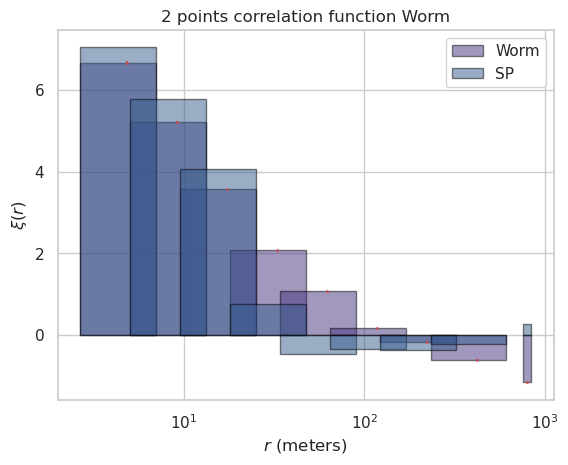

EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 388
min DD 0
maxRR 787
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998847736625515
normalization RR  1.0
[53.33530941 33.44738813 25.22609655 18.41273761  2.50570477 -1.48208998
 -1.35819317 -1.59030651 -1.04795265  0.96210724]
[ 7.50575311  6.69557059  5.21273207  3.57392546  2.05784058  1.07222358
  0.16436208 -0.17036349 -0.60456451 -1.18035418]
3
0.22301881647850602
[0.22301881647850602]
243 271 5
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 772
min DD 0
maxRR 791
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  1.0
normalization DR  0.9998839169909208
normalization RR  1.0
5 3 3.590098769259313


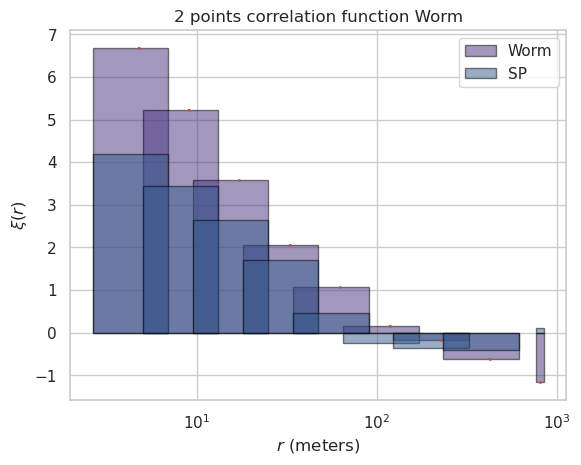

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 419
min DD 0
maxRR 792
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  1.0
normalization DR  0.9998802083333334
normalization RR  1.0
[28.58746725 13.42344446  9.17377471  6.87879902  5.03761407  2.16232623
 -1.20237113 -1.53014611 -1.04263651  0.91105577]
[ 7.50575311  6.69557059  5.21273207  3.57392546  2.05784058  1.07222358
  0.16436208 -0.17036349 -0.60456451 -1.18035418]
3
0.3052844229958537
[0.3052844229958537]
256 207 4
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 771
min DD 0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

maxRR 795
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  1.0
normalization DR  0.9998084953203744
normalization RR  1.0
4 4 6.742482857008778


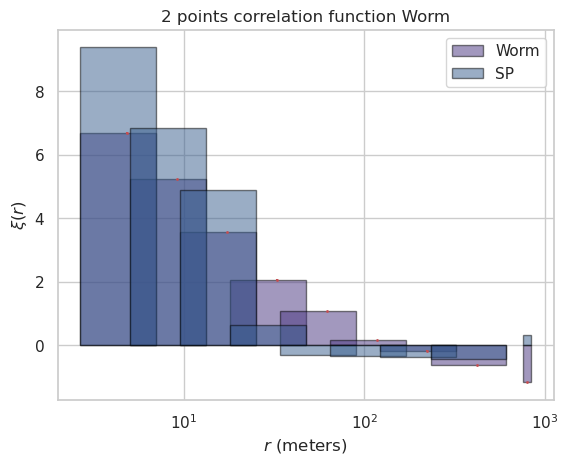

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

rmax  800.9999999999998
rmin 2.5354878376178767
max DD 403
min DD 0
maxRR 791
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  1.0
normalization DR  0.9997626666666667
normalization RR  1.0
[27.77916316 18.32054531 13.43540551  6.8740796   5.20755417  0.57112651
 -1.16819589 -1.57239897 -0.82154681  0.93521968]
[ 7.50575311  6.69557059  5.21273207  3.57392546  2.05784058  1.07222358
  0.16436208 -0.17036349 -0.60456451 -1.18035418]
3
0.30778997305331124
[0.30778997305331124]
625 501 4
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 794
min DD 0
maxRR 790
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  1.0
normalization DR  0.9998250444049733
normalization RR  1.0
4 5 4.576031215047788


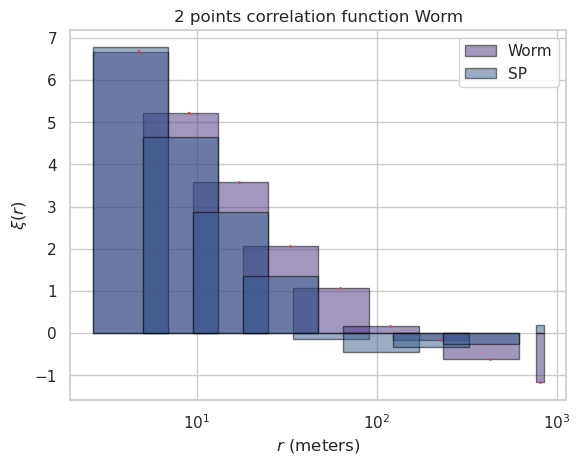

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 387
min DD 0
maxRR 793
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  1.0
normalization DR  0.9999058641975309
normalization RR  1.0
[25.26072572 18.58685864 16.82414559 12.11357452  6.89452338 -0.3595631
 -1.32459536 -1.60454331 -1.17647913  0.90482682]
[ 7.50575311  6.69557059  5.21273207  3.57392546  2.05784058  1.07222358
  0.16436208 -0.17036349 -0.60456451 -1.18035418]
3
0.27296980903593493
[0.27296980903593493]
216 197 3
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


...

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()


EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 763
min DD 0
maxRR 798
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  1.0
normalization DR  0.9998902340597255
normalization RR  1.0
3 6 2.920753700899958


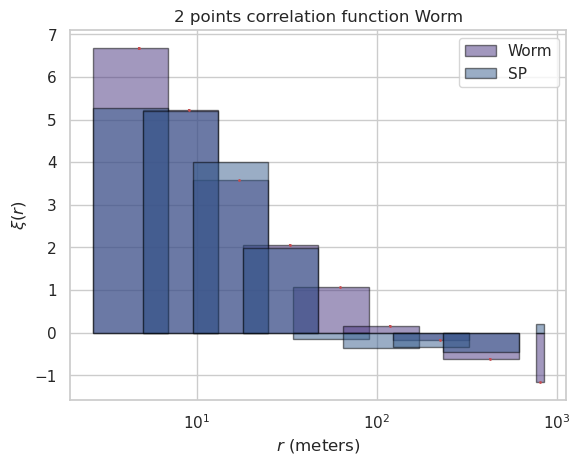

In [181]:
iteration_pure_SP = 1 #number of try to set the basis of the SOneira-Peebles 2pcf
number_of_try_for_each_parameter = 1 #number of generated 2pcf SP+random by set of paraemters to compare with the reference

save_dist,save_L,save_random = find_the_fit_parameters_SP_random(l_cluster,N,R,gdf_edge,crs,rmax,number_of_try_for_each_parameter,iteration_pure_SP)

## save the generative parameters

In [182]:
save_dir =  Path.cwd().parent /Path(f"out/fitted_parameters_SP/{name}")

dico_results["iteration_pure_SP"] = iteration_pure_SP
dico_results["number_of_try_for_each_parameter"] = number_of_try_for_each_parameter
dico_results["euclidean_distance_generated_empirical"] = save_dist
dico_results["list_L_generated"] = save_L
dico_results["list_l_cluster"] = l_cluster
dico_results["lsit_number_random_generated"] = save_random
slp.save_results(save_dir,dico_results)

In [183]:
dico_results

{'r_edges': array([  2.53548784,   4.80608714,   9.11007076,  17.26839045,
         32.73271048,  62.04575571, 117.60944159, 222.931941  ,
        422.57364417, 801.        ]),
 'xi': array([[ 7.50575311,  6.69557059,  5.21273207,  3.57392546,  2.05784058,
          1.07222358,  0.16436208, -0.17036349, -0.60456451, -1.18035418],
        [ 7.51378735,  6.7004078 ,  5.24832349,  3.5795686 ,  2.06510149,
          1.07387658,  0.16697784, -0.17572826, -0.61765388, -1.16054132],
        [ 7.50113676,  6.62833491,  5.19610645,  3.58133481,  2.07326645,
          1.06859545,  0.14961488, -0.15725219, -0.61655541, -1.1710269 ]]),
 'distance_distribution': array([  3,   6,  11, ...,  50, 117,  66], dtype=int32),
 'fit_SP': array([  0.55140863, 108.49569507]),
 'covariance_fit': array([[ 4.41492202e-03, -2.51844420e+00],
        [-2.51844420e+00,  1.68636841e+03]]),
 'number_points': 300,
 'clustering': array([2, 3, 4, 5, 6]),
 'silhouette_score': [[0.8050402343598038,
   0.7890153642685275,
 

# Compute the Kullback Leibler divergence 

In [184]:
def compare_log_distribution(n_short,n_iteration,l,eta,L,R,gdf_edge,crs,number_point,random_point,erase_nodes,k,rmax,scale,nbins,country_distribution,show_histplot=False):
    KL_distanceSP = 1000
    KL_distance_random =1000
    positionSP,position_random = 0,0
    r_bins = np.logspace(np.log10(100),np.log10(np.max(country_distribution)+1),nbins)
    country_distribution_log = mtpc.binning_data(country_distribution,nbins,r_bins)
    save_random = 0
    save_SP = 0
    l_inter_SP = []
    l_inter_random = []
    l_inter_SP_short = []
    l_inter_random_short = []
    for i in range(n_iteration):
        position = check_inside(l,eta,L,R,gdf_edge,erase_nodes)
        d = {}
        d["x"] = position.T[0]
        d["y"] = position.T[1]
        #df = pd.DataFrame((position))
        gdf = gpd.GeoDataFrame(
              d, geometry=gpd.points_from_xy(position.T[0], position.T[1]),crs=crs)
        gdf_random_square = gdf_edge.sample_points(random_point)
        gdf_random_points = gpd.GeoDataFrame(gdf_random_square.explode().get_coordinates(),geometry=gdf_random_square.explode(),crs=crs)
        gdf = gpd.GeoDataFrame(pd.concat( [gdf,gdf_random_points], ignore_index=True))
        #print(len(gdf))
        l_index = [i for i in range(len(gdf))]
        to_drop = np.random.choice(l_index,size=len(l_index)-N,replace=False)
        gdf.drop(to_drop, inplace=True)
       # print(len(gdf))
        position = gdf.get_coordinates().values
        r_edge,l_xi_SP = make_2pcf_for_model(position,crs,0,gdf_edge,rmax)
        plot_two_2pcf(r_edges,l_xi,l_xi_SP)
        #ax = gdf_edge.plot()
        #gdf.plot(ax=ax,color="red",markersize=0.5)
        #plt.show()
        gdf_projected_random= mtpc.generate_random_point(gdf_edge,number_point,crs,check_gpd=True)
        #r_edges_random_SP,l_xi_random_SP = mtpc.PCF_with_variance(gdf_projected_random,gdf_edge,crs,N_run,size,k,rmax,scale,nbins=nbins)
        distance_distribution_random_nobin = mtpc.compute_DD(gdf_projected_random)
        distance_distribution_SP_nobin = mtpc.compute_DD(gdf)
        distance_distribution_SP = mtpc.binning_data(distance_distribution_SP_nobin,nbins,r_bins)[0:nbins]
        distance_distribution_random = mtpc.binning_data(distance_distribution_random_nobin,nbins,r_bins)[0:nbins]

        distance_distribution_random = distance_distribution_random/np.sum(distance_distribution_random)
        distance_distribution_SP = distance_distribution_SP/np.sum(distance_distribution_SP)
        KL_distanceSP_inter = entropy(country_distribution_log[0:n_short]+1,distance_distribution_SP[0:n_short]+1)
        KL_distance_random_inter = entropy(country_distribution_log[0:n_short]+1,distance_distribution_random[0:n_short]+1)
        l_inter_SP_short.append(KL_distanceSP_inter)
        l_inter_random_short.append(KL_distance_random_inter)
        KL_distanceSP_inter = entropy(country_distribution_log+1,distance_distribution_SP+1)
        KL_distance_random_inter = entropy(country_distribution_log+1,distance_distribution_random+1)
        l_inter_SP.append(KL_distanceSP_inter) 
        l_inter_random.append(KL_distance_random_inter)
        if show_histplot:
            stat="density"
            sns.histplot(country_distribution,bins=nbins,stat="density",label="original",legend=True,log_scale=True)
            sns.histplot(distance_distribution_SP_nobin,bins=nbins,stat="density",label="SP",legend=True,log_scale=True)
            sns.histplot(distance_distribution_random_nobin,bins=nbins,stat="density",label="random",legend=True,log_scale=True)
            plt.yscale("log")
            plt.legend()
            plt.show()
    return l_inter_SP,l_inter_random,l_inter_SP_short,l_inter_random_short

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()


rmax  800.9999999999998
rmin 2.5354878376178767
max DD 787
min DD 0
maxRR 791
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998844444444445
normalization RR  1.0


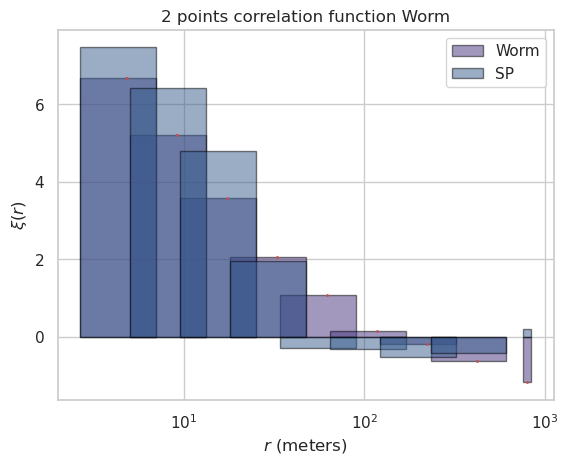

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 752
min DD 0
maxRR 793
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998622222222222
normalization RR  1.0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

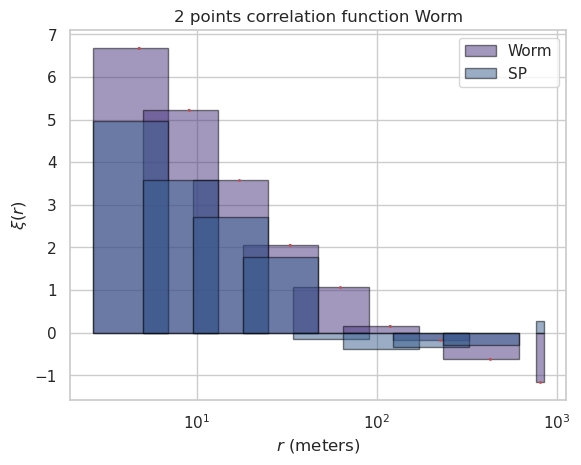

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 762
min DD 0
maxRR 791
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998544444444445
normalization RR  1.0


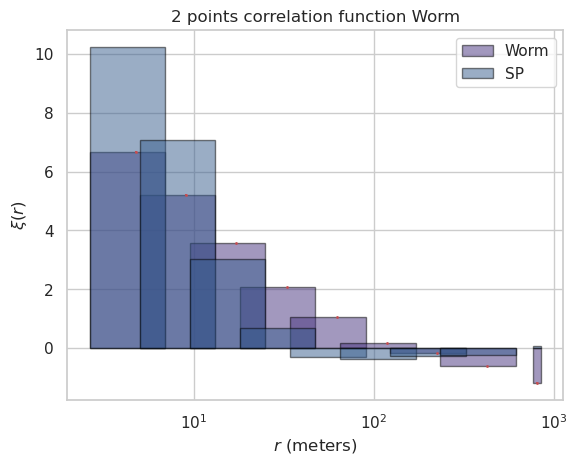

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 773
min DD 0
maxRR 789


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998666666666667
normalization RR  1.0


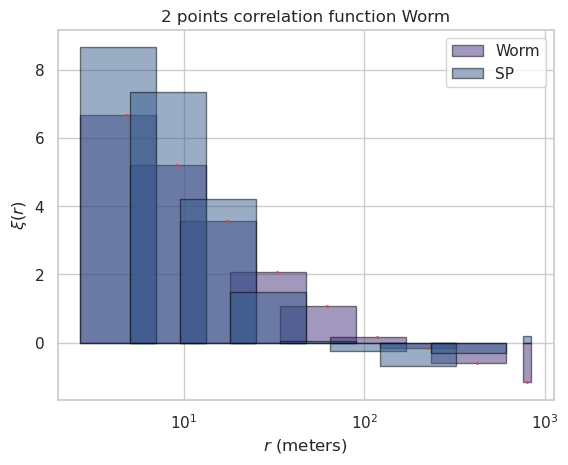

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


...

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 776
min DD 0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

maxRR 793
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998588888888889
normalization RR  1.0


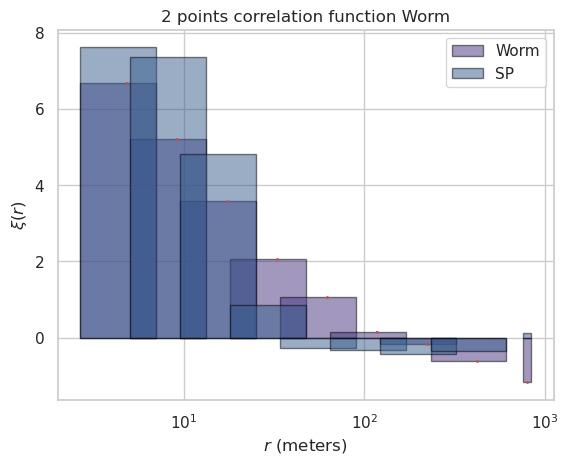

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 742
min DD 0
maxRR 797
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998377777777778
normalization RR  1.0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

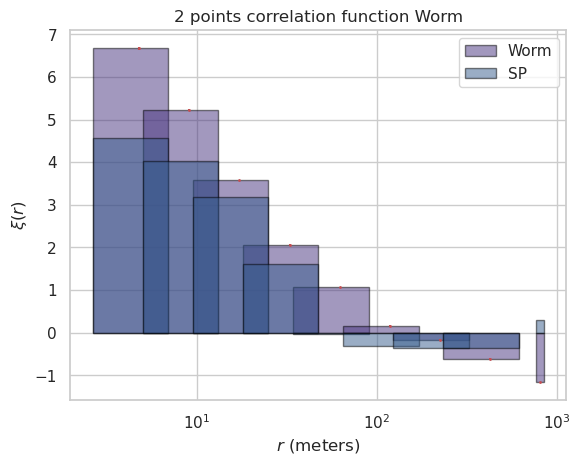

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 790
min DD 0
maxRR 784
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998666666666667
normalization RR  1.0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

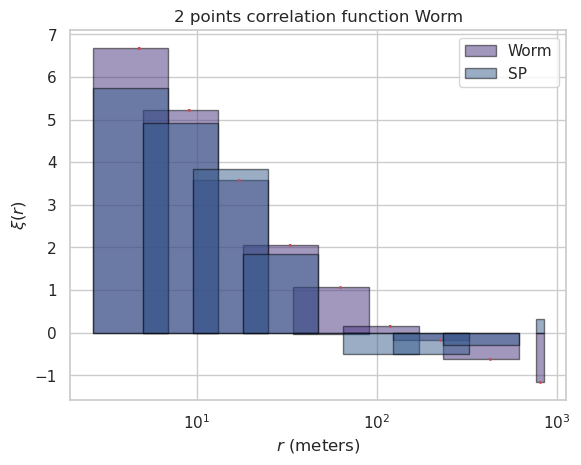

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 760
min DD 0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

maxRR 793
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998855555555556
normalization RR  1.0


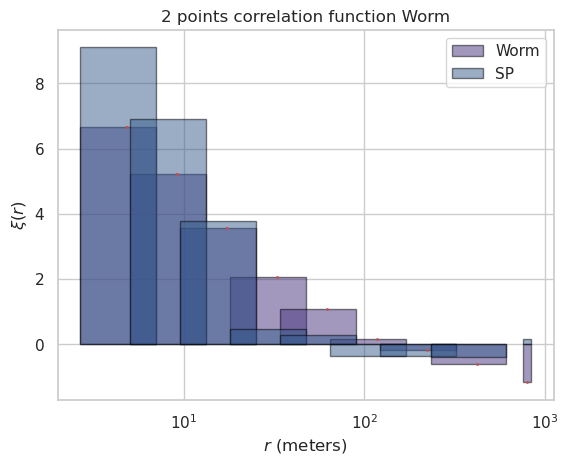

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 778
min DD 0
maxRR 794
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998711111111112
normalization RR  1.0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

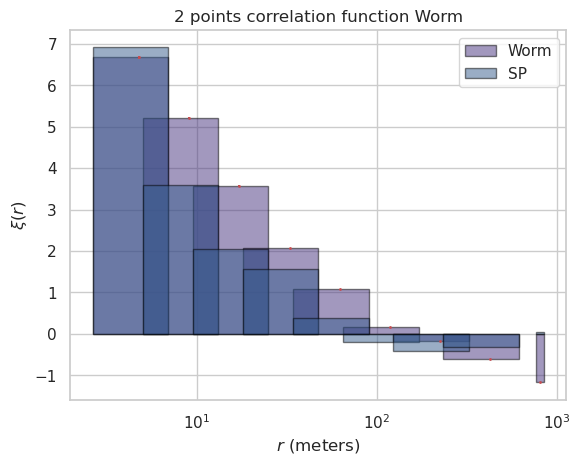

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 772
min DD 0
maxRR 787
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.99983
normalization RR  1.0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

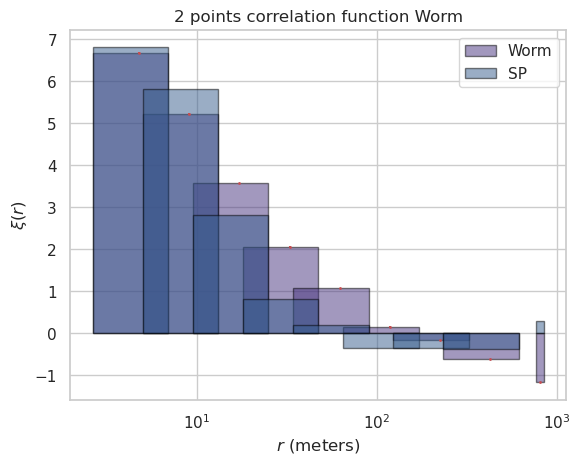

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


...

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 772
min DD 0
maxRR 789
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998633333333333
normalization RR  1.0


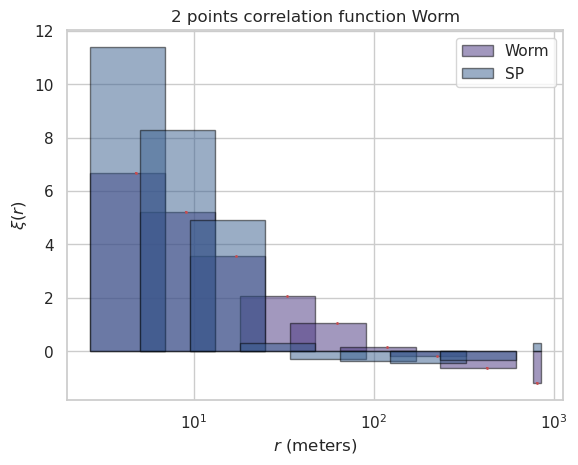

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 722
min DD 0
maxRR 792
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998188888888889
normalization RR  1.0


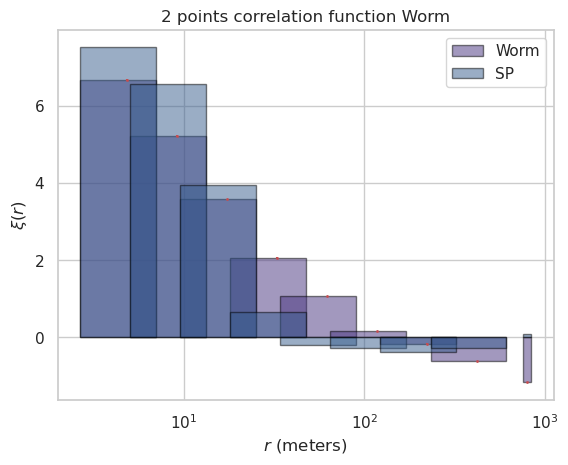

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 785
min DD 0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

maxRR 794
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.99986
normalization RR  1.0


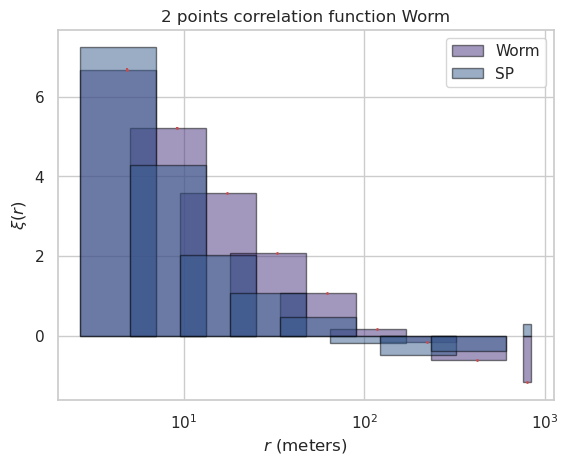

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 776
min DD 0
maxRR 795
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998755555555555
normalization RR  1.0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()


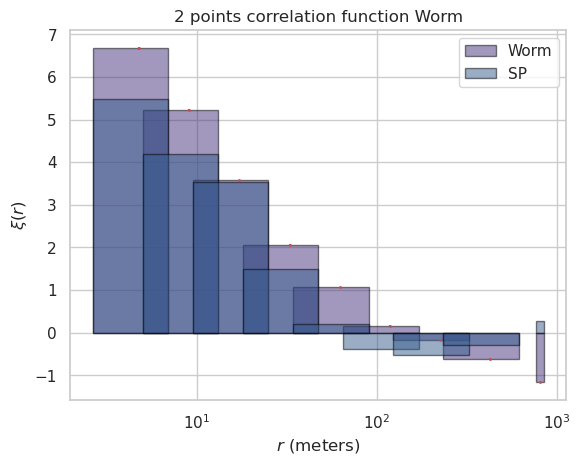

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 765
min DD 0
maxRR 793
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.99989
normalization RR  1.0


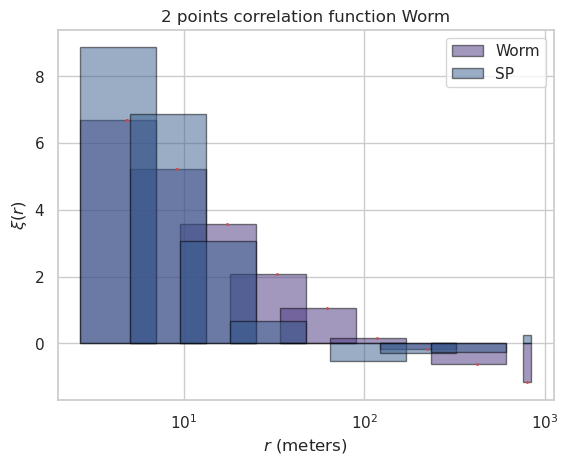

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 776
min DD 0
maxRR 793
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998966666666667
normalization RR  1.0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

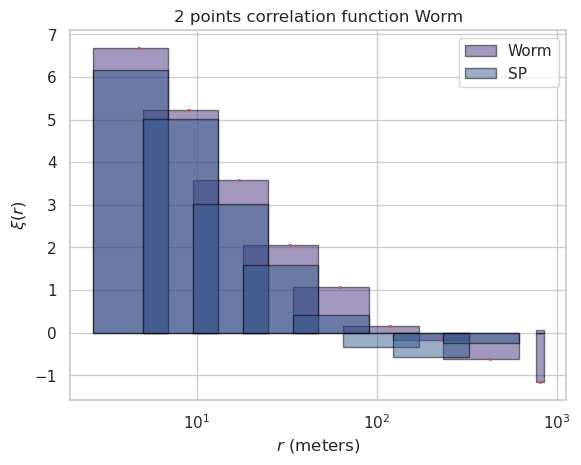

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

rmax  800.9999999999998
rmin 2.5354878376178767
max DD 739
min DD 0
maxRR 792
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998633333333333
normalization RR  1.0


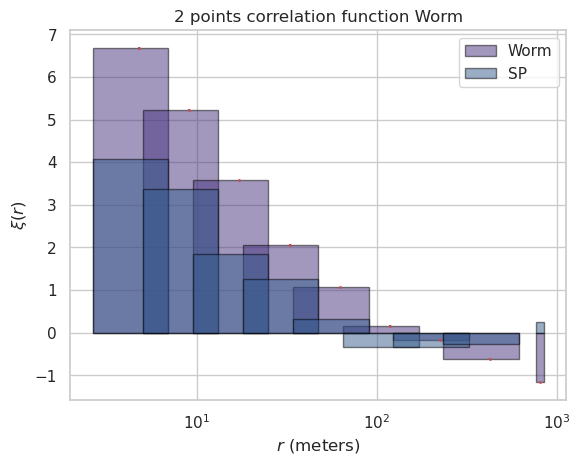

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


...

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()


rmax  800.9999999999998
rmin 2.5354878376178767
max DD 770
min DD 0
maxRR 795
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998244444444444
normalization RR  1.0


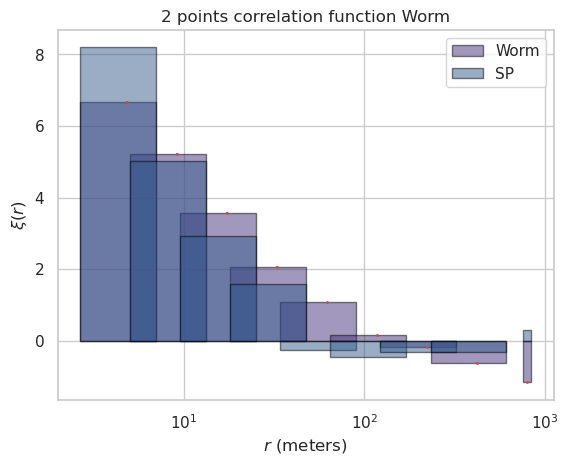

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


...

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 728
min DD 0
maxRR 792
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998466666666667
normalization RR  1.0


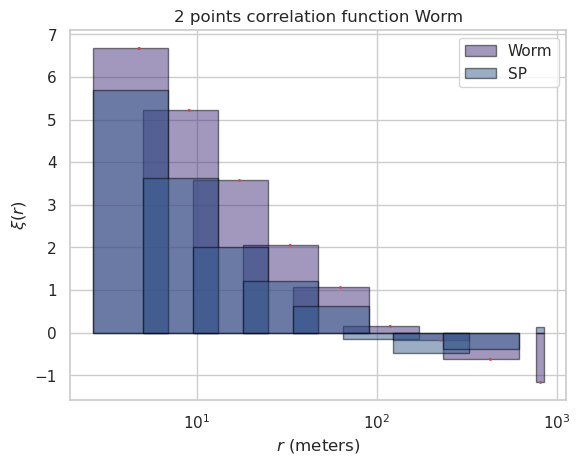

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 761
min DD 0
maxRR 796
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998811111111111
normalization RR  1.0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

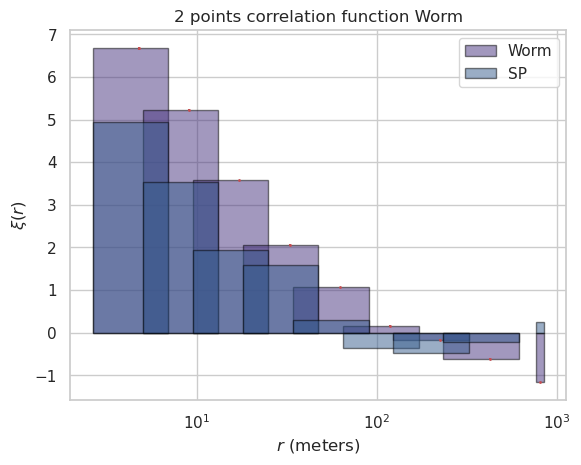

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 759
min DD 0
maxRR 791
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998444444444444
normalization RR  1.0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

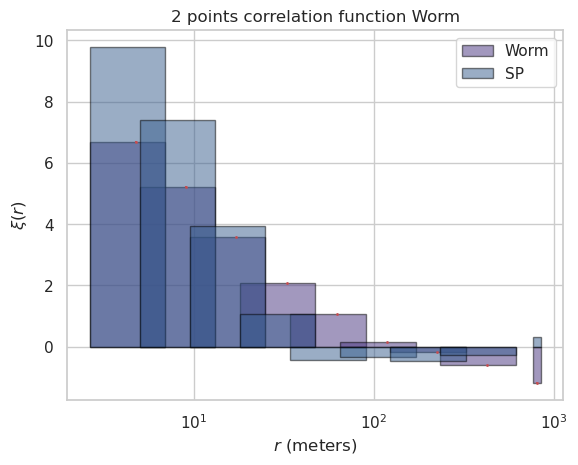

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


...

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 752
min DD 0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

maxRR 789
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998277777777778
normalization RR  1.0


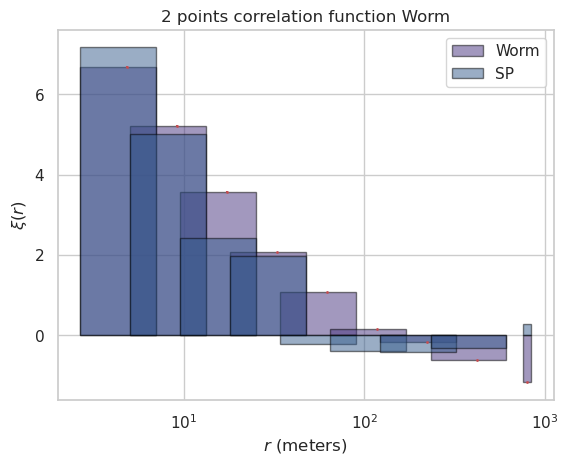

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 739
min DD 0
maxRR 793
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998711111111112
normalization RR  1.0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

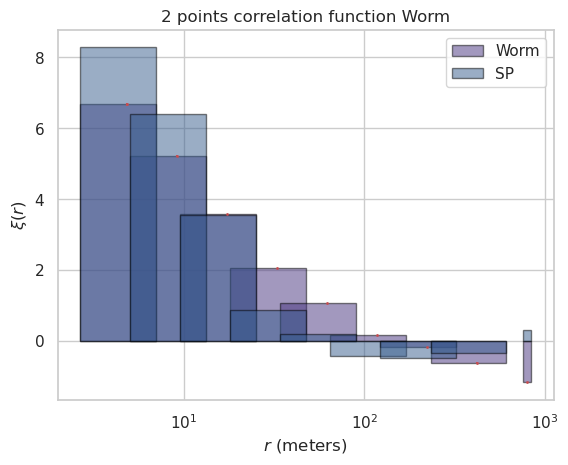

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 740
min DD 0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

maxRR 790
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998677777777778
normalization RR  1.0


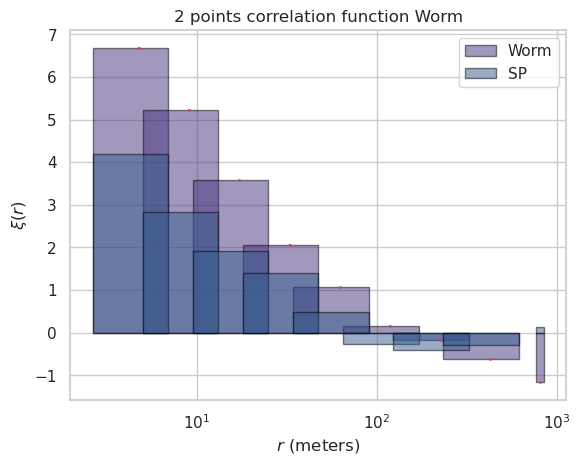

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 759
min DD 0
maxRR 796
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998655555555556
normalization RR  1.0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()


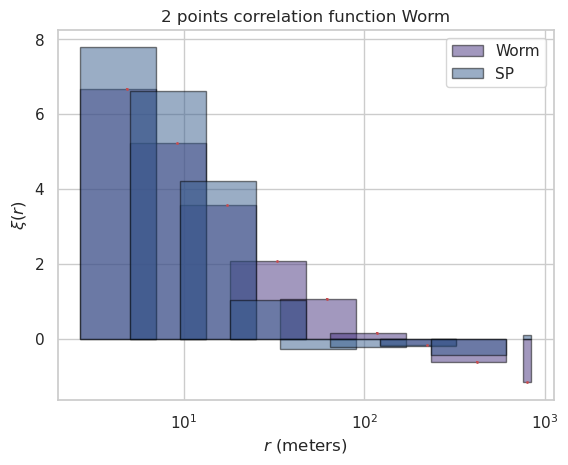

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 783
min DD 0
maxRR 794
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998844444444445
normalization RR  1.0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

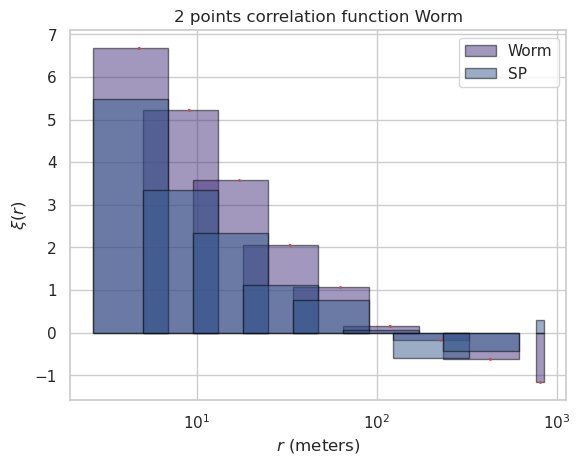

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


...

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 784
min DD 0
maxRR 797
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998677777777778
normalization RR  1.0


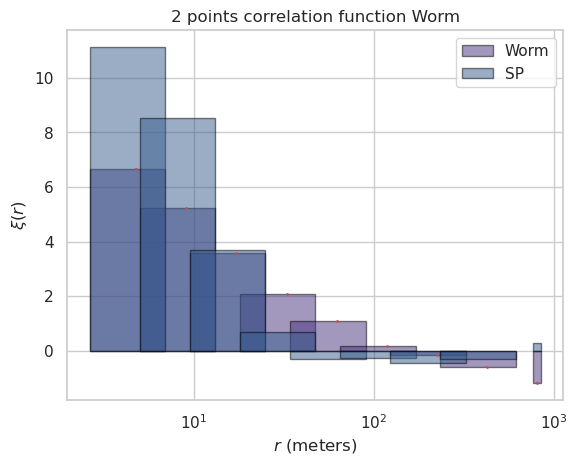

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


...

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 780
min DD 0
maxRR 794
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998366666666667
normalization RR  1.0


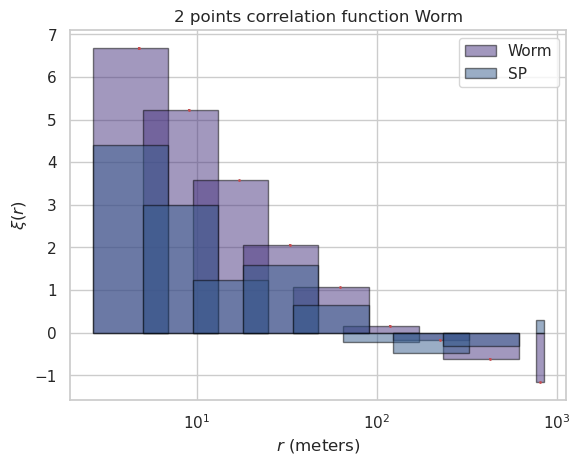

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 780
min DD 0
maxRR 788
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998433333333333
normalization RR  1.0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

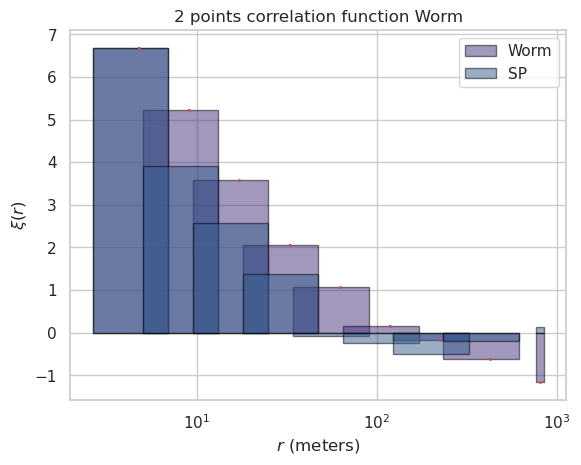

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 740
min DD 0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

maxRR 793
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998455555555555
normalization RR  1.0


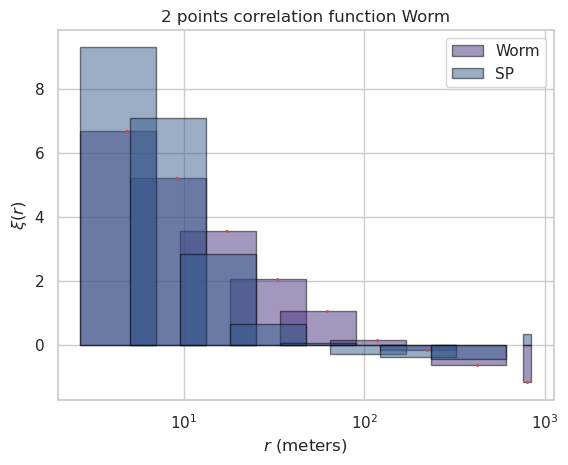

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 786
min DD 0
maxRR 784
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998477777777778
normalization RR  1.0


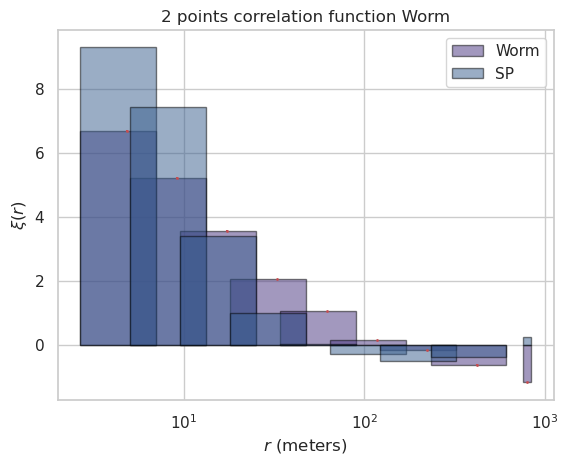

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


...

/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 764
min DD 0
maxRR 791
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998344444444445
normalization RR  1.0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()


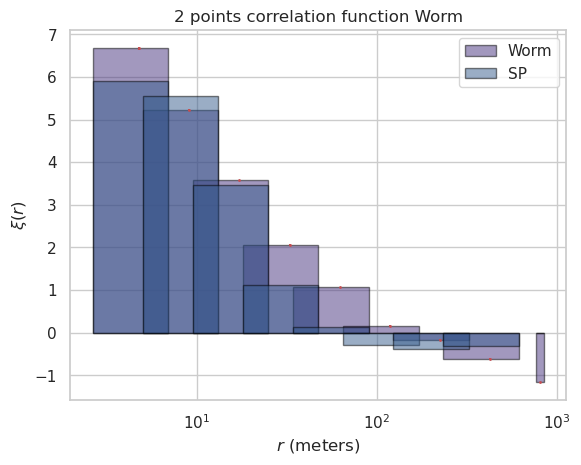

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 756
min DD 0
maxRR 794
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.99986
normalization RR  1.0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

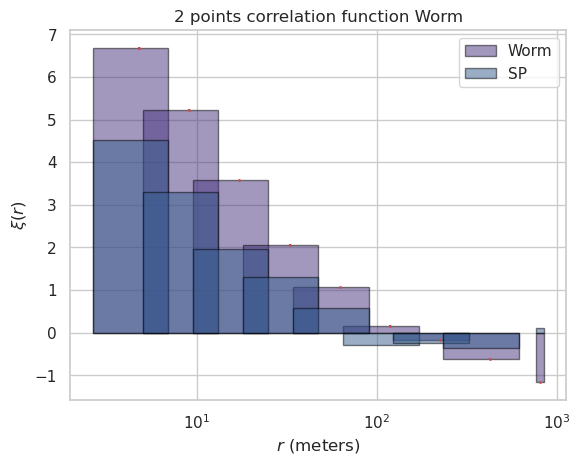

EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 772
min DD 0
maxRR 793
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998811111111111
normalization RR  1.0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()


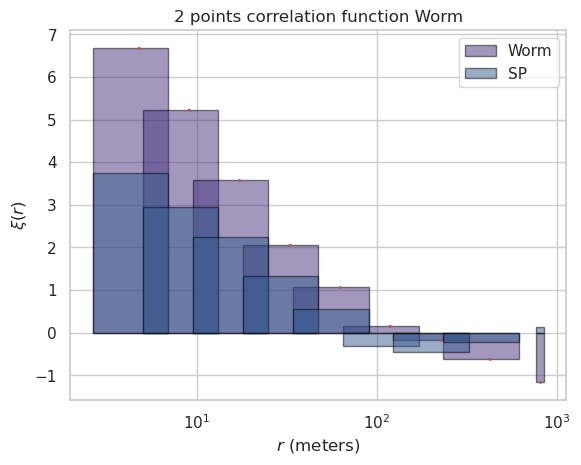

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 787
min DD 0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

maxRR 790
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998533333333334
normalization RR  1.0


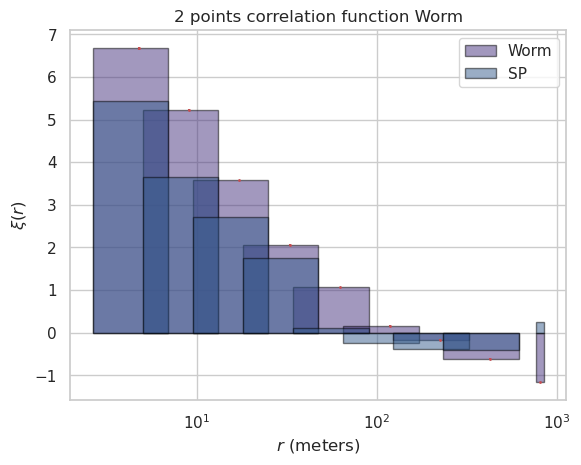

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


...

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()


rmax  800.9999999999998
rmin 2.5354878376178767
max DD 753
min DD 0
maxRR 784
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998377777777778
normalization RR  1.0


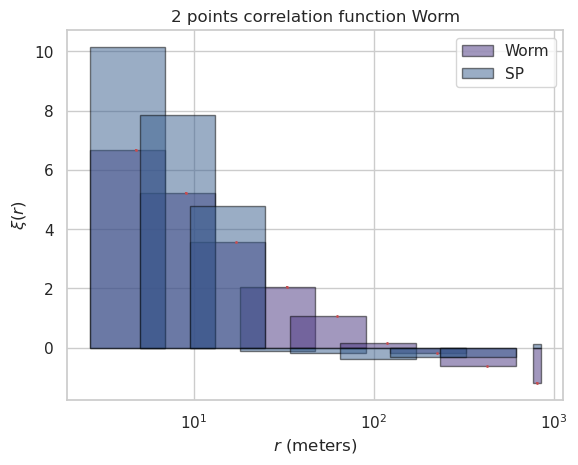

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


...

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 736
min DD 0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

maxRR 794
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998177777777778
normalization RR  1.0


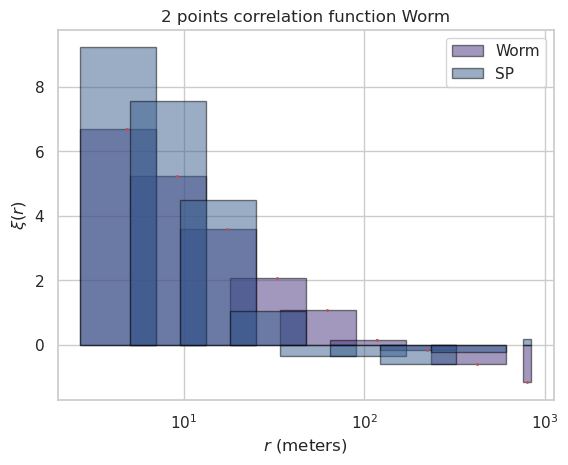

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 745
min DD 0
maxRR 789
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998988888888889
normalization RR  1.0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

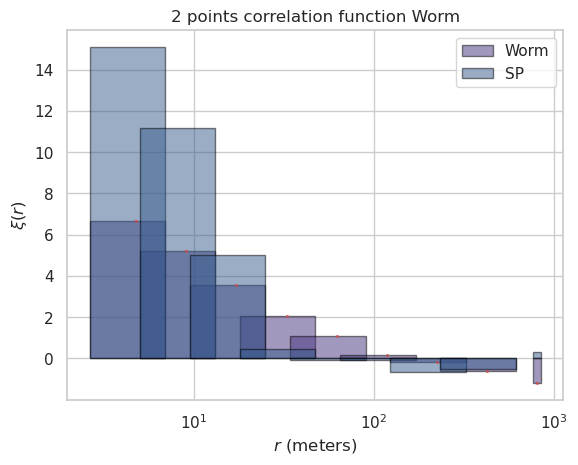

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 779
min DD 0
maxRR 794
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998588888888889
normalization RR  1.0


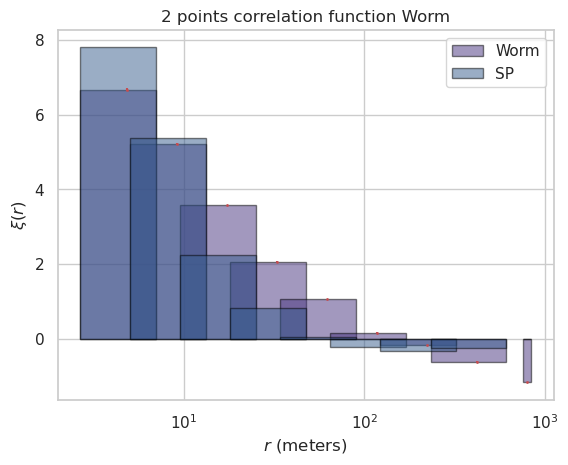

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 750
min DD 0
maxRR 795
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998688888888889
normalization RR  1.0


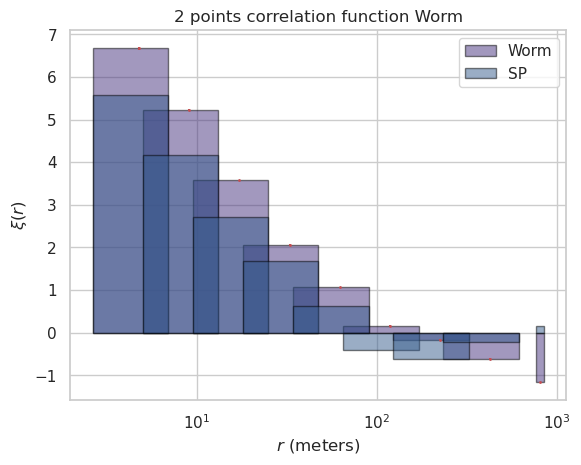

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


...

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 768
min DD 0
maxRR 795
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.99983
normalization RR  1.0


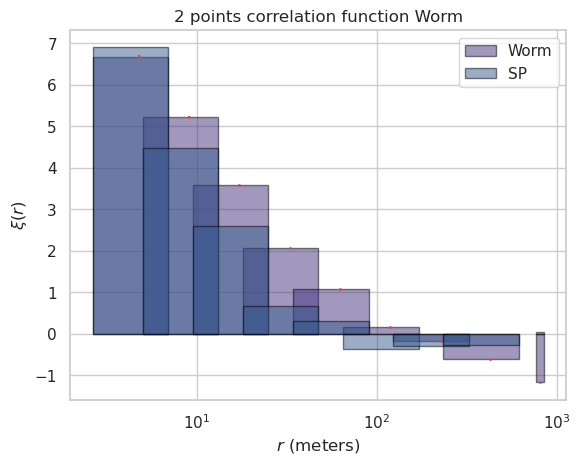

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

rmax  800.9999999999998
rmin 2.5354878376178767
max DD 762
min DD 0
maxRR 793
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.99986
normalization RR  1.0


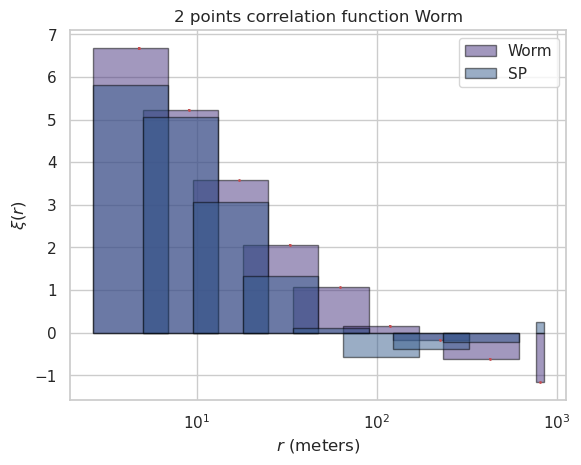

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


...

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 760
min DD 0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

maxRR 794
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998666666666667
normalization RR  1.0


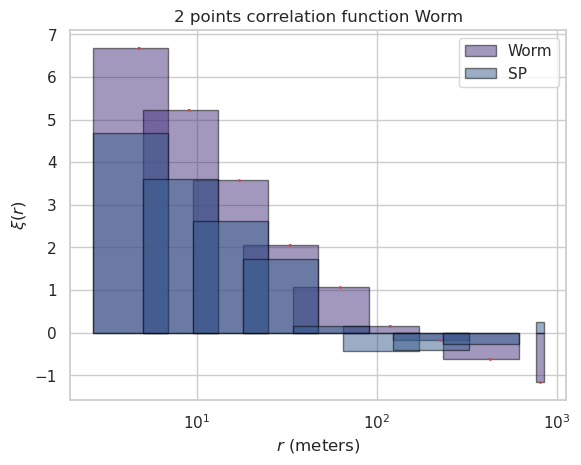

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


...

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

rmax  800.9999999999998
rmin 2.5354878376178767
max DD 756
min DD 0
maxRR 793
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998533333333334
normalization RR  1.0


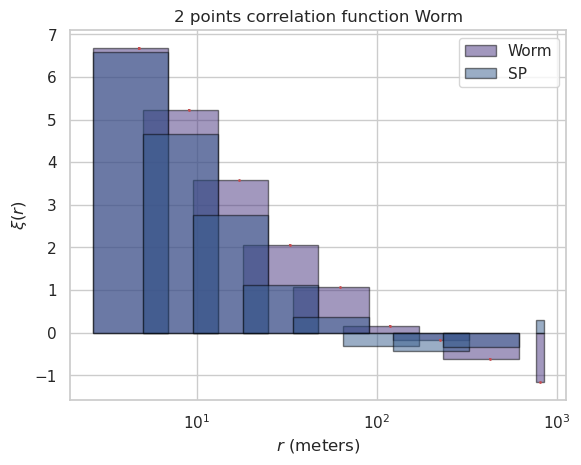

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


...

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 765
min DD 0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

maxRR 789
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998222222222222
normalization RR  1.0


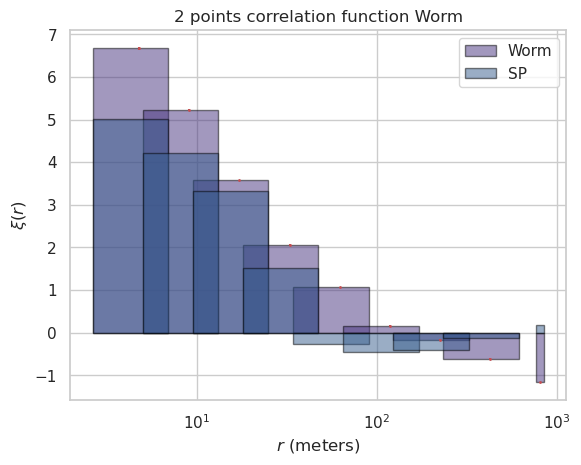

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 750
min DD 0
maxRR 790
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998377777777778
normalization RR  1.0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

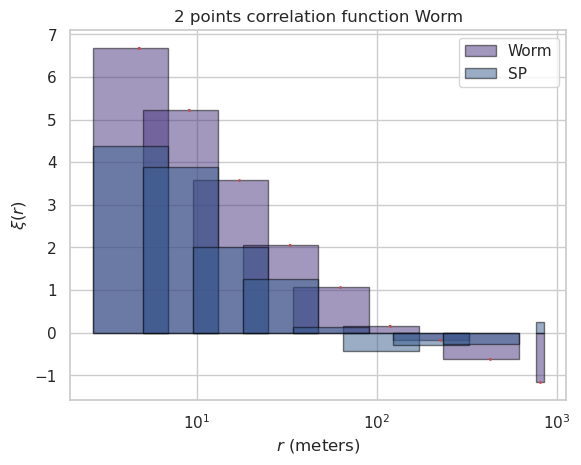

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


...

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 744
min DD 0
maxRR 789
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998655555555556
normalization RR  1.0


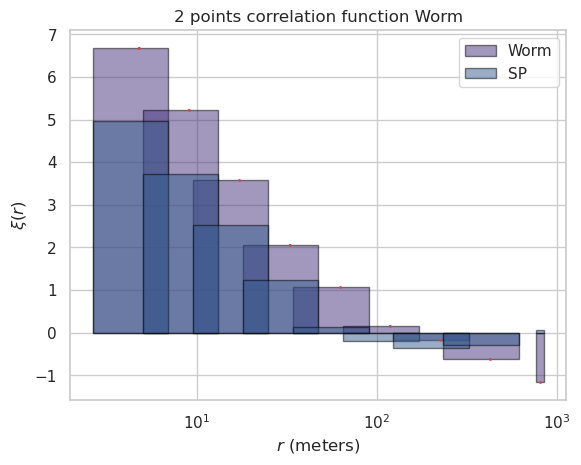

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 768
min DD 0
maxRR 787
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998933333333333
normalization RR  1.0


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()


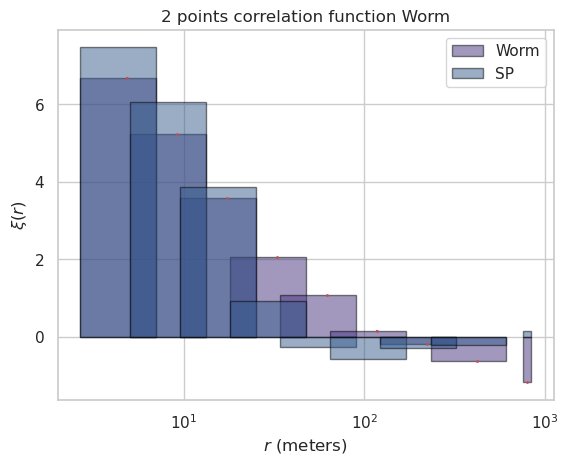

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


...

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()


EPSG:4979
EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 753
min DD 0
maxRR 793
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.99986
normalization RR  1.0


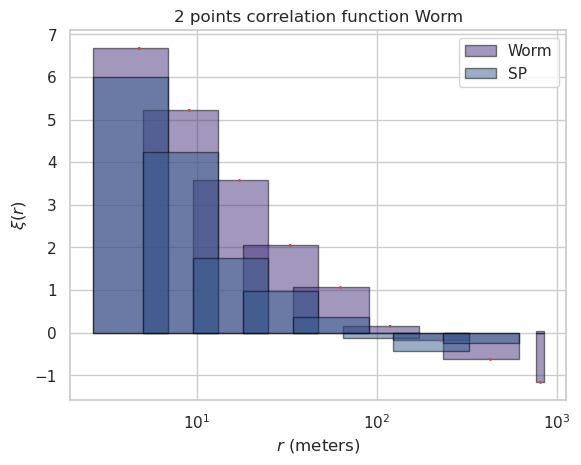

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

rmax  800.9999999999998
rmin 2.5354878376178767
max DD 739
min DD 0
maxRR 792
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998711111111112
normalization RR  1.0


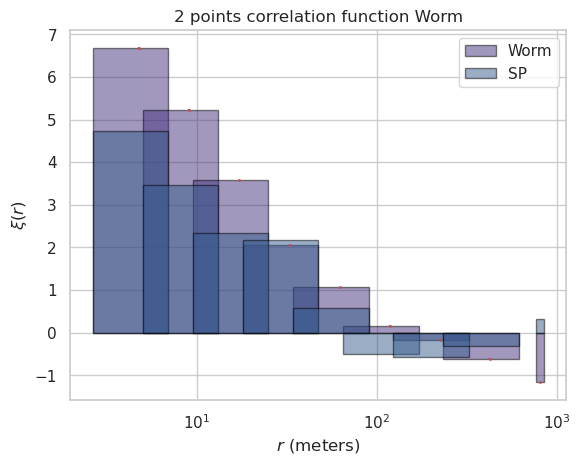

In [185]:
n_iteration = 50 # number of distribution to make
n_short = 10 # number of bins of small range to consider in KL_short
show_histplot = False
L = save_L[np.argmin(save_dist)] #np.argmin(save_dist)
eta = l_cluster[np.argmin(save_dist)]
l = eta**(1/(2-gamma))
random_point = save_random[np.argmin(save_dist)]
# KLSP,KLrandom
KLSP,KLrandom,KLSP_short,KLrandom_short = compare_log_distribution(n_short,n_iteration,l,eta,L,R,gdf_edge,crs,N,random_point,erase_nodes,k,rmax,scale,nbins,country_distribution,show_histplot)

TtestResult(statistic=49.450799737692286, pvalue=8.421139725284089e-49, df=57.475470606462515)


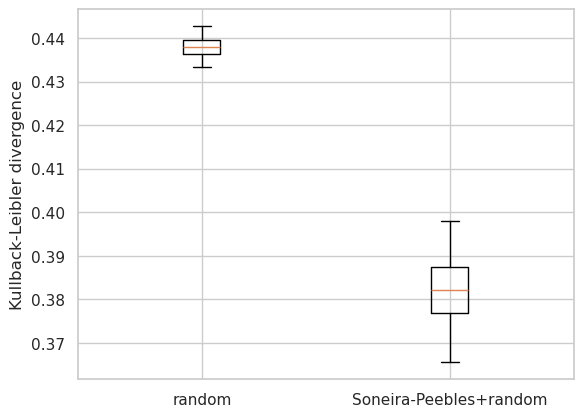

In [186]:
plt.boxplot([KLrandom,KLSP],labels=["random","Soneira-Peebles+random"])
plt.ylabel("Kullback-Leibler divergence")
plt.savefig(plot_dir / ("KL_"+name), format="png",transparent=True)
from scipy.stats import ttest_ind
print(ttest_ind(KLrandom,KLSP,equal_var=False))

TtestResult(statistic=49.450799737692286, pvalue=8.421139725284089e-49, df=57.475470606462515)


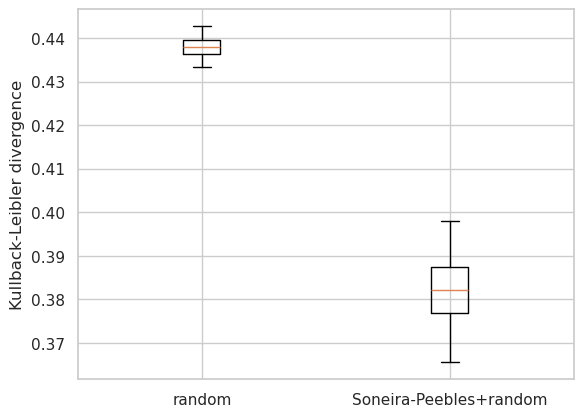

In [187]:
plt.boxplot([KLrandom_short,KLSP_short],labels=["random","Soneira-Peebles+random"])
plt.ylabel("Kullback-Leibler divergence")
plt.savefig(plot_dir / ("KL_short_"+name), format="png",transparent=True)
print(ttest_ind(KLrandom_short,KLSP_short,equal_var=False))

# Save the fitted parameters

In [188]:
L = save_L[np.argmin(save_dist)] #np.argmin(save_dist)
eta = l_cluster[np.argmin(save_dist)]
l = eta**(1/(2-gamma))
random_point = save_random[np.argmin(save_dist)]
dico_results["save_dist"] = save_dist
dico_results["L"] = save_L
dico_results["eta"] = l_cluster
dico_results["save_random"] = save_random
slp.save_results(save_dir,dico_results)

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
rmax  800.9999999999998
rmin 2.5354878376178767
max DD 769
min DD 0
maxRR 794
minRR 0
rmin,rmax= 2.5354878376178767 800.9999999999998
lenRR 10
lenDD 10
normalization DD  0.9999999999999999
normalization DR  0.9998445349626612
normalization RR  1.0


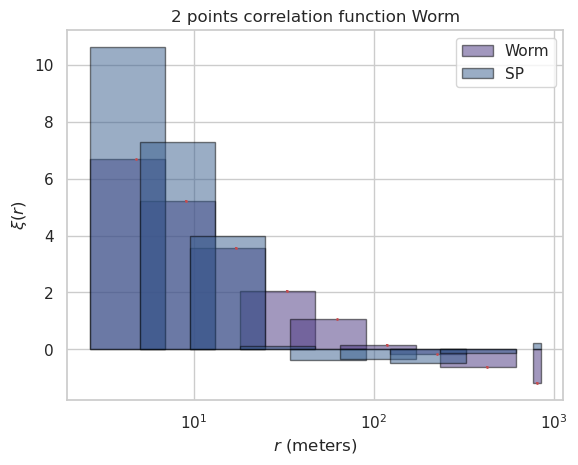

In [142]:
position = check_inside(l,eta,L,R,gdf_edge)
r_edges_random_SP,l_xi_random_SP = make_2pcf_for_model(position,crs,random_point,gdf_edge,rmax)
plot_two_2pcf(r_edges,l_xi,l_xi_random_SP)

In [143]:
print(save_L[np.argmin(save_dist)],l_cluster[np.argmin(save_dist)])

8 2


# Plot an example of the point sprinkle with fitted parameters on the map

EPSG:4979
256
300


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()


<Axes: >

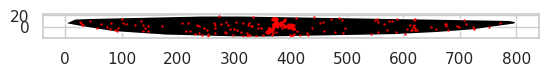

In [144]:
position = check_inside(l,eta,L,R,gdf_edge)
d = {}
d["x"] = position.T[0]
d["y"] = position.T[1]
gdf = gpd.GeoDataFrame(d, geometry=gpd.points_from_xy(position.T[0], position.T[1]),crs=crs)
print(len(gdf))
gdf_random_square = gdf_edge.sample_points(random_point)
gdf_random_points = gpd.GeoDataFrame(gdf_random_square.explode().get_coordinates(),geometry=gdf_random_square.explode(),crs=crs)
gdf = gpd.GeoDataFrame(pd.concat( [gdf,gdf_random_points], ignore_index=True))
l_index = [i for i in range(len(gdf))]
to_drop = np.random.choice(l_index,size=len(l_index)-N,replace=False)
gdf.drop(to_drop, inplace=True)
print(len(gdf))
convex_hull_polygon = gdf.union_all()
polygon = convex_hull_polygon.convex_hull
geoserie = gpd.GeoSeries(polygon)
squares_gdf=gpd.GeoDataFrame({'geometry': geoserie, 'df':[1]},crs=crs)
fig,ax = plt.subplots()
#squares_gdf.plot(ax=ax)
gdf_edge.plot(ax=ax,color="black")
gdf.plot(ax=ax,color="red",markersize=0.5)

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


...

/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979


/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  position = gdf_edge.centroid.get_coordinates().to_numpy()
/tmp/ipykernel_41847/1425828284.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to

EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
EPSG:4979
256
300


<Axes: >

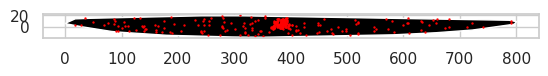

In [145]:
position = check_inside(l,eta,L,R,gdf_edge)
d = {}
d["x"] = position.T[0]
d["y"] = position.T[1]
gdf = gpd.GeoDataFrame(d, geometry=gpd.points_from_xy(position.T[0], position.T[1]),crs=crs)
print(len(gdf))
gdf_random_square = gdf_edge.sample_points(random_point)
gdf_random_points = gpd.GeoDataFrame(gdf_random_square.explode().get_coordinates(),geometry=gdf_random_square.explode(),crs=crs)
gdf = gpd.GeoDataFrame(pd.concat( [gdf,gdf_random_points], ignore_index=True))
l_index = [i for i in range(len(gdf))]
to_drop = np.random.choice(l_index,size=len(l_index)-N,replace=False)
gdf.drop(to_drop, inplace=True)
print(len(gdf))
convex_hull_polygon = gdf.union_all()
polygon = convex_hull_polygon.convex_hull
geoserie = gpd.GeoSeries(polygon)
squares_gdf=gpd.GeoDataFrame({'geometry': geoserie, 'df':[1]},crs=crs)
fig,ax = plt.subplots()
#squares_gdf.plot(ax=ax)
gdf_edge.plot(ax=ax,color="black")
gdf.plot(ax=ax,color="red",markersize=0.5)